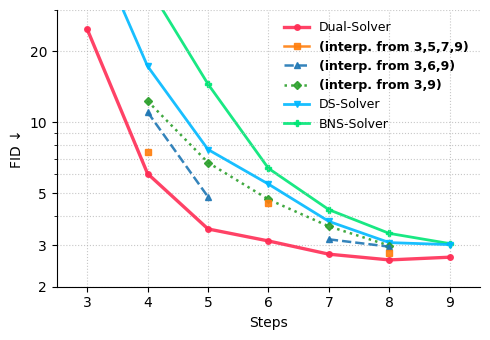

In [2]:
PALETTES = [
    ["#FF2D55", "#00B8FF", "#00E676"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"],  # Classic Blue–Orange–Green
    ["#d62728", "#1f77b4", "#7f7f7f"],  # Muted Red–Blue–Gray
    ["#4c78a8", "#f58518", "#54a24b"],  # Vega-Altair Set
    ["#2b83ba", "#abdda4", "#fdae61"],  # Nature Inspired
    ["#e69f00", "#56b4e9", "#009e73"],  # CUD (color-blind friendly)
    ["#377eb8", "#e41a1c", "#4d4d4d"],  # Cool–Warm–Neutral
    ["#8c510a", "#01665e", "#f5f5f5"],  # Earth Tone
    ["#e41a1c", "#377eb8", "#4daf4a"],  # Bold & Bright
    ["#984ea3", "#ff7f00", "#66a61e"],  # Dark Pastel
    ["#000000", "#7f7f7f", "#e6e6e6"],  # Grayscale Emphasis
]

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import numpy as np

steps = np.array([3, 4, 5, 6, 7, 8, 9])

# 곡선 정의: id, label, 값, 스타일을 한 번에 관리
curves = [
    dict(
        id="dual_base",
        label="Dual-Solver",
        vals=np.array([24.91, 6.05, 3.52, 3.13, 2.75, 2.60, 2.67]),
        style=dict(color=PALETTES[0][0], lw=2.4, ls="-",  marker="o", zorder=6),
    ),
    dict(
        id="dual_3579",
        label="(interp. from 3,5,7,9)",
        vals=np.array([np.nan, 7.48, np.nan, 4.53, np.nan, 2.79, np.nan]),
        style=dict(color=PALETTES[1][1], lw=1.8, ls="-",  marker="s", zorder=5),
    ),
    dict(
        id="dual_369",
        label="(interp. from 3,6,9)",
        vals=np.array([np.nan, 11.05, 4.82, np.nan, 3.18, 2.96, np.nan]),
        style=dict(color=PALETTES[1][0], lw=1.8, ls="--", marker="^", zorder=4),
    ),
    dict(
        id="dual_39",
        label="(interp. from 3,9)",
        vals=np.array([np.nan, 12.31, 6.74, 4.70, 3.61, 2.99, np.nan]),
        style=dict(color=PALETTES[1][2], lw=1.8, ls=":",  marker="D", zorder=3),
    ),
    dict(
        id="ds",
        label="DS-Solver",
        vals=np.array([67.31, 17.31,  7.66,  5.46,  3.79,  3.08,  3.02]),
        style=dict(color=PALETTES[0][1], lw=2.0, ls="-",  marker="v", zorder=2),
    ),
    dict(
        id="bns",
        label="BNS-Solver",
        vals=np.array([103.26, 38.20, 14.53,  6.37,  4.25,  3.37,  3.05]),
        style=dict(color=PALETTES[0][2], lw=2.0, ls="-",  marker="P", zorder=1),
    ),
]

fig, ax = plt.subplots(figsize=(5, 3.5))

lines = {}
handles = []

for c in curves:
    st = c["style"]
    vals = c["vals"]
    (line,) = ax.plot(
        steps,
        vals,
        label=c["label"],
        marker=st["marker"],
        linewidth=st["lw"],
        linestyle=st["ls"],
        color=st["color"],
        markersize=4,
        zorder=st["zorder"],
        alpha=0.9,
    )
    lines[c["id"]] = line
    handles.append(line)

ax.set_xlabel("Steps")
ax.set_ylabel("FID ↓")
ax.set_xticks(steps)
ax.set_xlim(2.5, 9.5)
ax.set_yscale("log")
yticks = [2, 3, 5, 10, 20, 50, 100]
ax.set_yticks(yticks)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _ : f"{y:g}"))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_ylim([2, 30])
ax.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(
    handles=handles,
    frameon=False,
    loc="upper right",
    fontsize=9.0,
)

# interpolation 라인만 bold 처리
for txt in leg.get_texts():
    if "interp. from" in txt.get_text():
        txt.set_fontweight("bold")

fig.tight_layout()
plt.show()
